<a href="https://colab.research.google.com/github/Sanika-tech123/Advanced-Machine-Learning-Practicals/blob/main/K_means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Mall_Customers.csv to Mall_Customers.csv
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
   

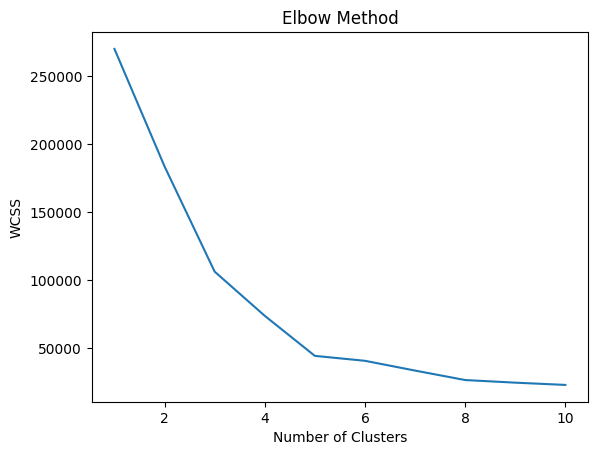

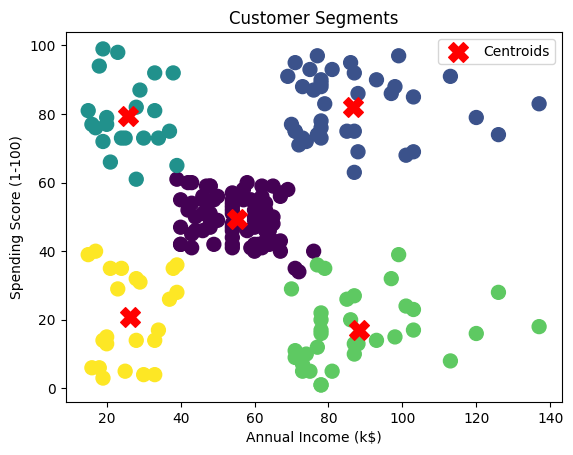

Cluster Centers:
[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


In [1]:
# Step 1 — Install Required Libraries
!pip install numpy pandas matplotlib seaborn scikit-learn

# Step 2 — Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from google.colab import files

# Step 3 — Upload and Load the Dataset

# Upload dataset
uploaded = files.upload()

# Load dataset
data = pd.read_csv("Mall_Customers.csv")

# Display first 5 rows
print(data.head())

# Step 4 — Explore the Dataset
print(data.info())
print(data.describe())

# Step 5 — Select Features for Clustering
X = data[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Step 6 — Determine Optimal Number of Clusters (Elbow Method)

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# Step 7 — Apply K-Means Clustering

kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Step 8 — Visualize the Clusters

plt.scatter(X[:,0], X[:,1], c=y_kmeans, cmap='viridis', s=100)
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            color='red',
            s=200,
            marker='X',
            label='Centroids')

plt.title("Customer Segments")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

# Step 9 — Print Cluster Centers

print("Cluster Centers:")
print(kmeans.cluster_centers_)
